# Predictor comparison — AlphaMissense vs CADD vs REVEL

Benchmarks three pathogenicity predictors on 292 CFTR variants with CFTR2 ground truth labels.

Requires `cftr2_results_annotated.csv` from `alphamissense.ipynb` and `All_Variants_VEP.Gene.vcf`.

In [2]:
import re
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

## Step 1. Load the 292 labelled variants

In [3]:
result = pd.read_csv("cftr2_results_annotated.csv")

binary = result[
    result["determination_2026"].isin(["CF-causing", "Non CF-causing"]) &
    result["am_pathogenicity"].notna()
].copy()
binary["label"] = (binary["determination_2026"] == "CF-causing").astype(int)

print(f"Labelled variants: {len(binary)}")
print(f"CF-causing    : {binary['label'].sum()}")
print(f"Non CF-causing: {(binary['label'] == 0).sum()}")

Labelled variants: 292
CF-causing    : 253
Non CF-causing: 39


## Step 2. Extract genomic coordinates from VCF

CADD needs chr, pos, ref, alt — not protein names.

In [4]:
protein_pattern = re.compile(r'p\.([A-Z][a-z]{2}\d+[A-Z][a-z]{2})')

variant_coords = {}

with open("All_Variants_VEP.Gene.vcf", encoding="utf-8", errors="replace") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        parts = line.strip().split("\t")
        if len(parts) < 5:
            continue
        chrom, pos, _, ref, alt = parts[0], parts[1], parts[2], parts[3], parts[4]
        match = protein_pattern.search(line)
        if match:
            name = match.group(1)
            if name not in variant_coords:
                variant_coords[name] = {"chrom": chrom, "pos": pos, "ref": ref, "alt": alt}

binary["chrom"] = binary["variant"].map({k: v["chrom"] for k, v in variant_coords.items()})
binary["pos"]   = binary["variant"].map({k: v["pos"]   for k, v in variant_coords.items()})
binary["ref"]   = binary["variant"].map({k: v["ref"]   for k, v in variant_coords.items()})
binary["alt"]   = binary["variant"].map({k: v["alt"]   for k, v in variant_coords.items()})

print(f"Coordinates found: {binary['pos'].notna().sum()} / {len(binary)}")
print(binary[["variant", "chrom", "pos", "ref", "alt"]].head())

Coordinates found: 292 / 292
    variant chrom        pos ref alt
0  Ser13Phe     7  117480132   C   T
1  Arg31Cys     7  117504290   C   T
6  Trp57Gly     7  117509038   T   G
7  Pro67Leu     7  117509069   C   T
9  Arg75Gln     7  117509093   G   A


In [5]:
CADD_URL = "https://cadd.gs.washington.edu/api/v1.0/{chrom}-{pos}-{ref}-{alt}"

def get_cadd_score(chrom, pos, ref, alt) -> float | None:
    try:
        url = CADD_URL.format(chrom=chrom, pos=pos, ref=ref, alt=alt)
        resp = requests.get(url, timeout=10)
        data = resp.json()
        if data and len(data) > 1:
            return float(data[1][5])  # PHRED score
        return None
    except Exception:
        return None

cadd_scores = []
for i, row in binary.iterrows():
    score = get_cadd_score(row["chrom"], row["pos"], row["ref"], row["alt"])
    cadd_scores.append(score)
    if len(cadd_scores) % 20 == 0:
        print(f"  {len(cadd_scores)} / {len(binary)} done")
    time.sleep(0.3)

binary["cadd_score"] = cadd_scores
print(f"\nCADD scored: {binary['cadd_score'].notna().sum()} / {len(binary)}")
print(binary[["variant", "cadd_score"]].head())


  20 / 292 done
  40 / 292 done
  60 / 292 done
  80 / 292 done
  100 / 292 done
  120 / 292 done
  140 / 292 done
  160 / 292 done
  180 / 292 done
  200 / 292 done
  220 / 292 done
  240 / 292 done
  260 / 292 done
  280 / 292 done

CADD scored: 0 / 292
    variant cadd_score
0  Ser13Phe       None
1  Arg31Cys       None
6  Trp57Gly       None
7  Pro67Leu       None
9  Arg75Gln       None


In [7]:
resp = requests.get(
    "https://cadd.gs.washington.edu/api/v1.0/GRCh38-v1.7/7:117480132_C_T",
    timeout=10
)
print(resp.status_code)
print(resp.text[:500])


200
[{"Alt":"T","Chrom":"7","PHRED":"29.4","Pos":"117480132","RawScore":"5.238939","Ref":"C"}]



In [8]:
CADD_URL = "https://cadd.gs.washington.edu/api/v1.0/GRCh38-v1.7/{chrom}:{pos}_{ref}_{alt}"

def get_cadd_score(chrom, pos, ref, alt) -> float | None:
    try:
        url = CADD_URL.format(chrom=chrom, pos=pos, ref=ref, alt=alt)
        resp = requests.get(url, timeout=10)
        data = resp.json()
        if data and len(data) > 0:
            return float(data[0]["PHRED"])
        return None
    except Exception:
        return None

cadd_scores = []
for i, row in binary.iterrows():
    score = get_cadd_score(row["chrom"], row["pos"], row["ref"], row["alt"])
    cadd_scores.append(score)
    if len(cadd_scores) % 20 == 0:
        print(f"  {len(cadd_scores)} / {len(binary)} done")
    time.sleep(0.3)

binary["cadd_score"] = cadd_scores
print(f"\nCADD scored: {binary['cadd_score'].notna().sum()} / {len(binary)}")
print(binary[["variant", "cadd_score"]].head())


  20 / 292 done
  40 / 292 done
  60 / 292 done
  80 / 292 done
  100 / 292 done
  120 / 292 done
  140 / 292 done
  160 / 292 done
  180 / 292 done
  200 / 292 done
  220 / 292 done
  240 / 292 done
  260 / 292 done
  280 / 292 done

CADD scored: 286 / 292
    variant  cadd_score
0  Ser13Phe        29.4
1  Arg31Cys        28.1
6  Trp57Gly        26.0
7  Pro67Leu        26.7
9  Arg75Gln        29.7


AlphaMissense AUC : 0.946
CADD AUC          : 0.776
Variants used     : 286


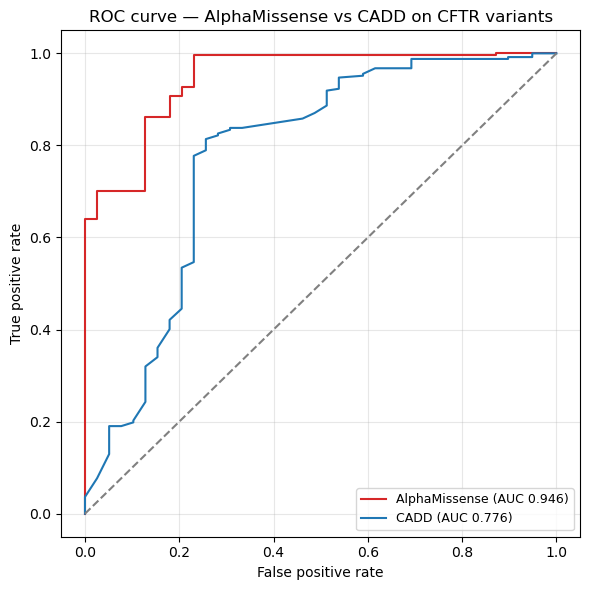

In [9]:
compare = binary[binary["cadd_score"].notna()].copy()

am_auc = roc_auc_score(compare["label"], compare["am_pathogenicity"])
cadd_auc = roc_auc_score(compare["label"], compare["cadd_score"])

print(f"AlphaMissense AUC : {am_auc:.3f}")
print(f"CADD AUC          : {cadd_auc:.3f}")
print(f"Variants used     : {len(compare)}")

# ROC curves
fig, ax = plt.subplots(figsize=(6, 6))

for name, scores, color in [
    ("AlphaMissense", compare["am_pathogenicity"], "#d62728"),
    ("CADD", compare["cadd_score"], "#1f77b4"),
]:
    fpr, tpr, _ = roc_curve(compare["label"], scores)
    auc = roc_auc_score(compare["label"], scores)
    ax.plot(fpr, tpr, color=color, label=f"{name} (AUC {auc:.3f})")

ax.plot([0,1],[0,1], linestyle="--", color="grey")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve — AlphaMissense vs CADD on CFTR variants")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
with open("All_Variants_VEP.Gene.vcf", encoding="utf-8", errors="replace") as f:
    for line in f:
        if "REVEL" in line and line.startswith("##"):
            print(line.strip())
            break


In [15]:
SIFT_INDEX = 31
POLYPHEN_INDEX = 32

csq_pattern = re.compile(r'CSQ=([^;]+)')
protein_pattern = re.compile(r'p\.([A-Z][a-z]{2}\d+[A-Z][a-z]{2})')

variant_scores = {}

with open("All_Variants_VEP.Gene.vcf", encoding="utf-8", errors="replace") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        csq_match = csq_pattern.search(line)
        if not csq_match:
            continue
        for transcript in csq_match.group(1).split(","):
            fields = transcript.split("|")
            if len(fields) <= POLYPHEN_INDEX:
                continue
            prot_match = protein_pattern.search(fields[11])
            if not prot_match:
                continue
            name = prot_match.group(1)
            sift = fields[SIFT_INDEX]
            polyphen = fields[POLYPHEN_INDEX]
            if name not in variant_scores and sift and polyphen:
                variant_scores[name] = {"sift": sift, "polyphen": polyphen}

print(f"Variants with SIFT/PolyPhen: {len(variant_scores)}")
print(list(variant_scores.items())[:3])


Variants with SIFT/PolyPhen: 2473
[('Ser13Phe', {'sift': 'deleterious_low_confidence(0)', 'polyphen': 'probably_damaging(0.999)'}), ('Arg31Cys', {'sift': 'deleterious_low_confidence(0)', 'polyphen': 'possibly_damaging(0.673)'}), ('Arg31Leu', {'sift': 'deleterious_low_confidence(0)', 'polyphen': 'benign(0.136)'})]


Variants with all four scores: 286

AlphaMissense   AUC: 0.946
CADD            AUC: 0.776
PolyPhen        AUC: 0.826
SIFT            AUC: 0.678


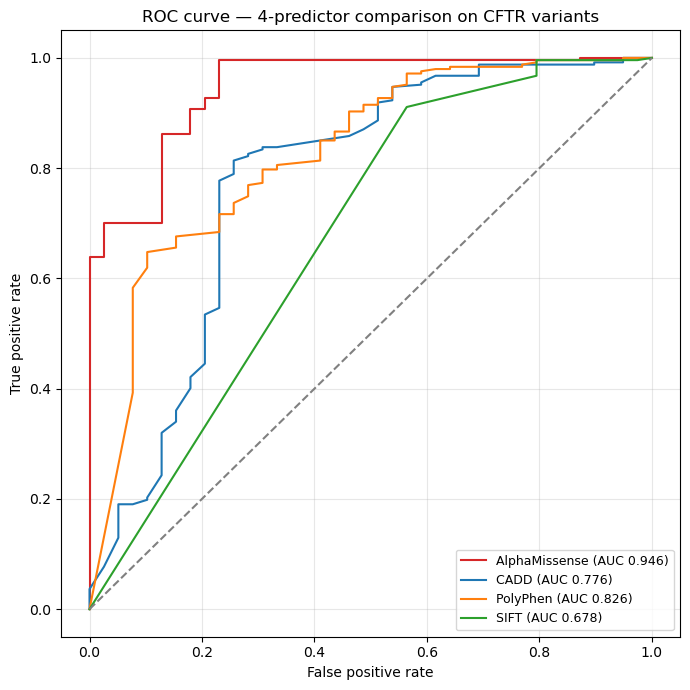

In [16]:
import re as re2

def parse_sift(s: str) -> float | None:
    m = re2.search(r'\(([0-9.]+)\)', s)
    if m:
        return 1 - float(m.group(1))  # invert: lower SIFT = more damaging
    return None

def parse_polyphen(s: str) -> float | None:
    m = re2.search(r'\(([0-9.]+)\)', s)
    return float(m.group(1)) if m else None

binary["sift_score"] = binary["variant"].map(
    {k: parse_sift(v["sift"]) for k, v in variant_scores.items()}
)
binary["polyphen_score"] = binary["variant"].map(
    {k: parse_polyphen(v["polyphen"]) for k, v in variant_scores.items()}
)

compare = binary[
    binary["cadd_score"].notna() &
    binary["sift_score"].notna() &
    binary["polyphen_score"].notna()
].copy()

print(f"Variants with all four scores: {len(compare)}")
print()

predictors = {
    "AlphaMissense": ("am_pathogenicity", "#d62728"),
    "CADD":          ("cadd_score",       "#1f77b4"),
    "PolyPhen":      ("polyphen_score",   "#ff7f0e"),
    "SIFT":          ("sift_score",       "#2ca02c"),
}

fig, ax = plt.subplots(figsize=(7, 7))
for name, (col, color) in predictors.items():
    fpr, tpr, _ = roc_curve(compare["label"], compare[col])
    auc = roc_auc_score(compare["label"], compare[col])
    ax.plot(fpr, tpr, color=color, label=f"{name} (AUC {auc:.3f})")
    print(f"{name:15} AUC: {auc:.3f}")

ax.plot([0,1],[0,1], linestyle="--", color="grey")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve — 4-predictor comparison on CFTR variants")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_4way.png", dpi=150, bbox_inches="tight")
plt.show()
